**Conditional Workflow Using LangGraph & Groq**


In [1]:
import os
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

load_dotenv()

d:\AgenticAI-LangGraph-projects\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
# Initialize Groq LLM
# We use Llama 3.3 70B for strong reasoning and structured output capabilities.
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

In [3]:
# 1. Define State
class SupportState(TypedDict):
    question: str
    category: str
    response: str

# 2. Define Structured Output for the Router
class RouteAction(BaseModel):
    category: Literal["billing", "technical", "general"] = Field(
        ..., 
        description="The category of the user's question."
    )

router_llm = llm.with_structured_output(RouteAction)

In [4]:
# 3. Define Nodes

def router_node(state: SupportState) -> SupportState:
    print("---ROUTING QUESTION---")
    question = state["question"]
    
    # Ask the LLM to classify
    result = router_llm.invoke(
        f"Classify this customer question into 'billing', 'technical', or 'general'.\n\nQuestion: {question}"
    )
    print(f"-> Routed to: {result.category.upper()}")
    
    return {"category": result.category}

def billing_node(state: SupportState) -> SupportState:
    print("---EXECUTING BILLING NODE---")
    prompt = f"You are a friendly billing assistant. Answer this question concisely: {state['question']}"
    result = llm.invoke(prompt)
    return {"response": result.content}

def tech_node(state: SupportState) -> SupportState:
    print("---EXECUTING TECH SUPPORT NODE---")
    prompt = f"You are an expert technical support engineer. Provide a step-by-step fix concisely: {state['question']}"
    result = llm.invoke(prompt)
    return {"response": result.content}

def general_node(state: SupportState) -> SupportState:
    print("---EXECUTING GENERAL NODE---")
    prompt = f"You are a helpful general customer service agent. Answer this question warmly: {state['question']}"
    result = llm.invoke(prompt)
    return {"response": result.content}

In [5]:
# 4. Define the Logic Edge
def route_decision(state: SupportState) -> str:
    """This function uses the state to decide which node to go to next."""
    # We just return the category, which matches the node names
    return state["category"]

In [6]:
# 5. Build Graph
graph = StateGraph(SupportState)

# Add nodes
graph.add_node("router", router_node)
graph.add_node("billing", billing_node)
graph.add_node("technical", tech_node)
graph.add_node("general", general_node)

# Add edges
graph.add_edge(START, "router")

# *CONDITIONAL EDGES*
# We add a conditional edge from the 'router' node
graph.add_conditional_edges(
    source="router",         # The node we are deciding FROM
    path=route_decision,     # The function that decides
    # Map the outcome of route_decision to destination nodes
    path_map={
        "billing": "billing",
        "technical": "technical",
        "general": "general"
    }
)

# Connect the specialized nodes to the end
graph.add_edge("billing", END)
graph.add_edge("technical", END)
graph.add_edge("general", END)

workflow = graph.compile()

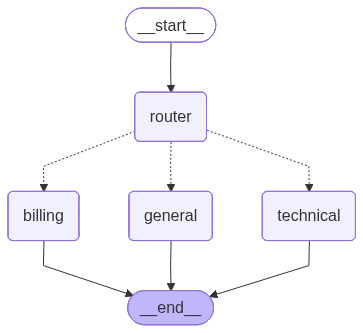

In [7]:
workflow

In [9]:
# 6. Test the Conditional Branching
questions = [
    "Why was I charged $50 this month instead of $30?",
    
]

for q in questions:
    print(f"\n\n[NEW QUESTION]: {q}")
    initial_state = {
        "question": q,
        "category": "",
        "response": ""
    }
    final_state = workflow.invoke(initial_state)
    print(f"\nFINAL RESPONSE:\n{final_state['response']}")



[NEW QUESTION]: Why was I charged $50 this month instead of $30?
---ROUTING QUESTION---
-> Routed to: BILLING
---EXECUTING BILLING NODE---

FINAL RESPONSE:
You were charged $50 this month because you upgraded to our premium service last month, which includes additional features for an extra $20. Your new monthly rate is $30 (standard rate) + $20 (premium upgrade) = $50.
